# Model Analysis

## Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df_train = pd.read_csv('../split/train.csv')
df_train.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,34.0,76.0,33.0,-331.0,3.584622,0.141838,0
1,50.0,80.0,31.2,-321.0,1.330551,45.004368,1
2,27.0,75.0,33.0,-173.0,2.332372,0.143433,0
3,29.0,70.0,33.4,-170.0,1.109906,0.362938,0
4,48.0,72.0,34.4,-131.0,0.029072,0.053782,0


In [3]:
X_test = df_train.drop("Target", axis=1)
y_test = df_train["Target"]

## Mode Evaluation

In [4]:
def evaluate_model(model, model_name):
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    y_prob = model.predict(X_test)
    y_predict = np.argmax(y_prob, axis=1)
    title = "Confustion Matrix - " + model_name

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

In [5]:
def tflite_predict(interpreter, X):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    outputs = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()

        y = interpreter.get_tensor(output_details[0]['index'])
        outputs.append(y[0])

    return np.array(outputs)

In [6]:
def evaluate_model_tflite(interpreter, model_name):
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    y_prob = tflite_predict(interpreter, X_test)
    y_predict = np.argmax(y_prob, axis=1)
    title = "Confusion Matrix - " + model_name

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

In [7]:
model = tf.keras.models.load_model('../model/ANN.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227 (4.80 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 776 (3.04 KB)

655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report

                    precision    recall  f1-score   support

      Low Activity       1.00      0.96      0.98     10686
High Computational       0.96      0.98      0.97      6736
 Network Intensive       0.93      0.99      0.96      3507

          accuracy                           0.97     20929
         macro avg       0.96      0.98      0.97     20929
      weighted avg       0.98      0.97      0.97     20929



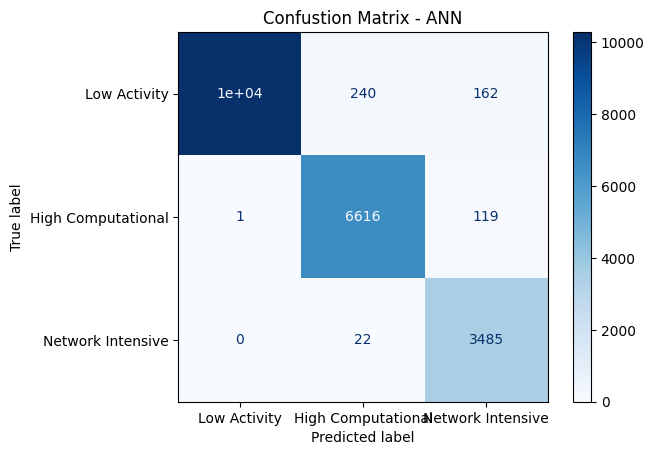

In [8]:
evaluate_model(model, "ANN")

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Classification Report

                    precision    recall  f1-score   support

      Low Activity       1.00      0.96      0.98     10686
High Computational       0.96      0.98      0.97      6736
 Network Intensive       0.93      0.99      0.96      3507

          accuracy                           0.97     20929
         macro avg       0.96      0.98      0.97     20929
      weighted avg       0.98      0.97      0.97     20929



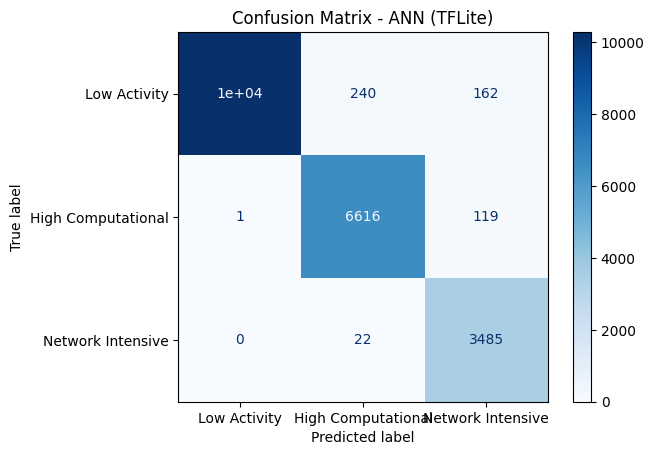

In [10]:
interpreter = tf.lite.Interpreter(model_path='../model/tflite/ANN.tflite')
interpreter.allocate_tensors()
evaluate_model_tflite(interpreter, "ANN (TFLite)")

In [11]:
model = tf.keras.models.load_model('../model/LR.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (264.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44 (180.00 B)

655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.86      0.90      0.88     10686
High Computational       0.82      0.76      0.79      6736
 Network Intensive       0.93      0.93      0.93      3507

          accuracy                           0.86     20929
         macro avg       0.87      0.86      0.87     20929
      weighted avg       0.86      0.86      0.86     20929



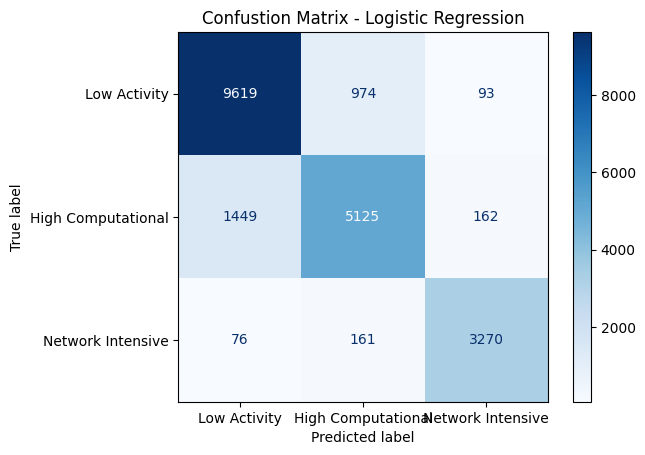

In [12]:
evaluate_model(model, "Logistic Regression")

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.86      0.90      0.88     10686
High Computational       0.82      0.76      0.79      6736
 Network Intensive       0.93      0.93      0.93      3507

          accuracy                           0.86     20929
         macro avg       0.87      0.86      0.87     20929
      weighted avg       0.86      0.86      0.86     20929



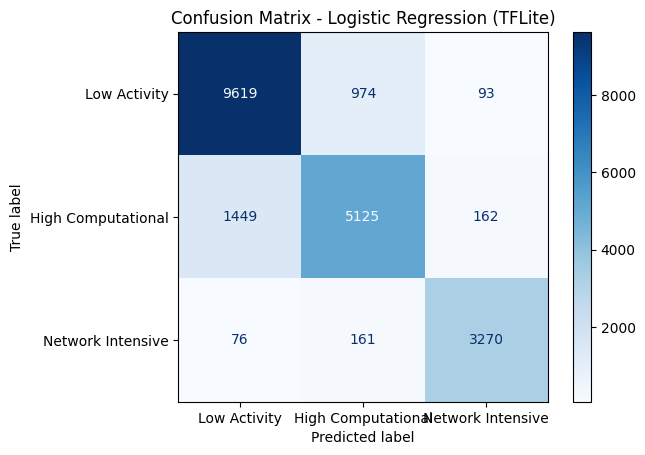

In [13]:
interpreter = tf.lite.Interpreter(model_path='../model/tflite/LR.tflite')
interpreter.allocate_tensors()
evaluate_model_tflite(interpreter, "Logistic Regression (TFLite)")